# Tái lập LightGCL trên Yelp

Trước khi áp dụng LightGCL cho Expedia, notebook này kiểm tra xem model trong [src/lightgcl.py](../src/lightgcl.py), cùng vòng lặp huấn luyện và cách đánh giá trong [src/utils.py](../src/utils.py), có cho ra đúng kết quả của paper trên chính bộ dữ liệu của paper hay không.

- **Dữ liệu:** bộ Yelp đã chia sẵn train/test trong repo [HKUDS/LightGCL](https://github.com/HKUDS/LightGCL) (`data/yelp/trnMat.pkl`, `data/yelp/tstMat.pkl`).
- **Cấu hình:** đúng giá trị mặc định của lệnh `python main.py --data yelp` trong repo gốc.
- **Mốc so sánh:** Table 6 (Appendix E) của [paper](https://arxiv.org/abs/2302.08191), là kết quả của code hiện có trên GitHub ("new setting"). Table 1 trong thân bài dùng setting cũ (mỗi batch lấy mẫu user trước rồi mới lấy positive/negative). Code của setting cũ không còn là bản chính, nên Table 1 chỉ để tham khảo.

| Yelp | Recall@20 | NDCG@20 | Recall@40 | NDCG@40 |
|---|---|---|---|---|
| Table 6, new setting (mốc so sánh) | 0,0985 | 0,0842 | 0,1553 | 0,1051 |
| Table 1, setting cũ | 0,0793 | 0,0668 | 0,1292 | 0,0852 |

## 0. Chuẩn bị

In [ ]:
import json
import numbers
import pickle
import platform
import sys
import time
import urllib.request
import warnings
from datetime import datetime, timezone
from functools import partial
from pathlib import Path
from types import SimpleNamespace

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from IPython.display import display
from tqdm.auto import tqdm

PROJECT_ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "src" / "lightgcl.py").is_file())
sys.path.insert(0, str(PROJECT_ROOT / "src"))
from lightgcl import LightGCL  # noqa: E402
from utils import normalize_adj, svd_view, to_torch_sparse, topk_metrics, train_epoch  # noqa: E402

DEVICE = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")


def fmt_num(x, digits=4):
    """37670293 -> '37.670.293', 0.12345 -> '0,1235' (at most `digits` decimals)."""
    text = f"{x:,.0f}" if float(x).is_integer() else f"{x:,.{digits}f}".rstrip("0").rstrip(".")
    return text.translate(str.maketrans(",.", ".,"))


def fmt_pct(x, digits=2):
    """0.359036 -> '35,90%'."""
    return f"{x:.{digits}%}".replace(".", ",")


def fmt_table(df):
    """Display copy of df: numbers in Vietnamese format, columns whose name contains '%' as percentages."""
    def cell(value, pct):
        if isinstance(value, bool) or not isinstance(value, numbers.Number):
            return value
        if pd.isna(value):
            return "—"
        return fmt_pct(value) if pct else fmt_num(value)

    out = df.astype(object)
    for col in df.columns:
        name = col[-1] if isinstance(col, tuple) else col
        out[col] = [cell(value, "%" in str(name)) for value in df[col]]
    return out


COLORS = {"model": "#2a78d6"}
INK = {"primary": "#0b0b0b", "secondary": "#52514e", "muted": "#898781", "grid": "#e1e0d9", "surface": "#fcfcfb"}
plt.rcParams.update({
    "figure.facecolor": INK["surface"],
    "axes.facecolor": INK["surface"],
    "axes.edgecolor": INK["grid"],
    "axes.labelcolor": INK["secondary"],
    "axes.titlecolor": INK["primary"],
    "axes.titlelocation": "left",
    "axes.titlesize": 12,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "axes.grid.axis": "y",
    "axes.axisbelow": True,
    "grid.color": INK["grid"],
    "grid.linewidth": 0.8,
    "xtick.color": INK["secondary"],
    "ytick.color": INK["secondary"],
    "legend.frameon": False,
    "text.color": INK["primary"],
})

gpu = torch.cuda.get_device_name(DEVICE) if DEVICE.type == "cuda" else "CPU"
print(f"Python {sys.version.split()[0]} | {platform.platform()}")
print(f"torch {torch.__version__} | numpy {np.__version__} | pandas {pd.__version__} | device {DEVICE} ({gpu})")
print(f"Run started (UTC): {datetime.now(timezone.utc):%Y-%m-%d %H:%M:%S}")

Python 3.11.16 | Linux-7.0.0-31-generic-x86_64-with-glibc2.43
torch 2.14.0+cu130 | numpy 2.4.6 | pandas 2.3.3 | device cuda:0 (NVIDIA GeForce RTX 4080)
Run started (UTC): 2026-09-30 02:35:37


### 0.2 Cấu hình

Cấu hình mặc định trong paper là: `d=64`, `gnn_layer=2`, `q=5`, `temp=0.2`, `lambda1=0.2`, `lambda2=1e-7`, `dropout=0`, `lr=1e-3`. Batch huấn luyện là `inter_batch=4096`; khi test, user được chia thành nhóm `batch=256`.

- **Không dừng sớm:** code gốc train đủ 100 epoch, test mỗi 3 epoch (epoch 0, 3, 6, …, đếm từ 0).
- **Seed:** code gốc không đặt seed; ở đây đặt seed để chạy lại được, nên kết quả có thể lệch đôi chút so với bất kỳ một lần chạy nào của tác giả.

In [ ]:
cfg = SimpleNamespace(
    d=64,
    gnn_layer=2,
    q=5,
    temp=0.2,
    lambda1=0.2,
    lambda2=1e-7,
    dropout=0.0,
    lr=1e-3,
    inter_batch=4096,   # training batch (edges)
    test_batch=256,     # users per test batch; the official metrics average over these batches
    epochs=100,
    test_every=3,
    topks=(20, 40),
    seed=2026,
)
PAPER = {
    "paper Table 6 (new setting)": {"recall@20": 0.0985, "ndcg@20": 0.0842, "recall@40": 0.1553, "ndcg@40": 0.1051},
    "paper Table 1 (setting cũ)": {"recall@20": 0.0793, "ndcg@20": 0.0668, "recall@40": 0.1292, "ndcg@40": 0.0852},
}
METRICS = list(PAPER["paper Table 6 (new setting)"])

np.random.seed(cfg.seed)
torch.manual_seed(cfg.seed)
GEN = torch.Generator(device=DEVICE).manual_seed(cfg.seed)  # negatives and batch order
print(json.dumps(vars(cfg)))

{"d": 64, "gnn_layer": 2, "q": 5, "temp": 0.2, "lambda1": 0.2, "lambda2": 1e-07, "dropout": 0.0, "lr": 0.001, "inter_batch": 4096, "test_batch": 256, "epochs": 100, "test_every": 3, "topks": [20, 40], "seed": 2026}


## 1. Dữ liệu

Hai file `trnMat.pkl` và `tstMat.pkl` được tải từ repo gốc vào `data/lightgcl_yelp/` (thư mục `data/` đã nằm trong `.gitignore`), rồi so với số liệu ở mục 4.1.1 của paper.

In [7]:
# Cell 1: Download (once) and load the official Yelp split
# Output: train (coo), test (csr), train_csr (binary csr), n_users, n_items
YELP_DIR = PROJECT_ROOT / "data" / "lightgcl_yelp"
YELP_URL = "https://raw.githubusercontent.com/HKUDS/LightGCL/main/data/yelp/"
YELP_DIR.mkdir(parents=True, exist_ok=True)
for name in ["trnMat.pkl", "tstMat.pkl"]:
    if not (YELP_DIR / name).is_file():
        urllib.request.urlretrieve(YELP_URL + name, YELP_DIR / name)


def load_pickle(path):
    # The pickles reference numpy/scipy module paths that are deprecated but still load.
    with warnings.catch_warnings(), open(path, "rb") as fh:
        warnings.simplefilter("ignore", DeprecationWarning)
        return pickle.load(fh)


train = load_pickle(YELP_DIR / "trnMat.pkl").tocoo()
test = load_pickle(YELP_DIR / "tstMat.pkl").tocsr()
n_users, n_items = train.shape
train_csr = (train != 0).astype(np.float32).tocsr()

data_summary = pd.DataFrame({
    "paper (mục 4.1.1)": {"user": 29_601, "item": 24_734, "tương tác": 1_069_128},
    "trnMat.pkl": {"user": n_users, "item": n_items, "tương tác": train.nnz},
    "tstMat.pkl": {"user": test.shape[0], "item": test.shape[1], "tương tác": test.nnz},
}).T
display(fmt_table(data_summary))
print(f"User có ít nhất một item test: {fmt_num((test.getnnz(axis=1) > 0).sum())}; "
      f"cặp (user, item) có ở cả train và test: {fmt_num(train_csr.multiply(test > 0).nnz)}")

,user,item,tương tác
paper (mục 4.1.1),29.601,24.734,1.069.128
trnMat.pkl,29.601,24.734,1.069.128
tstMat.pkl,29.601,24.734,305.466


User có ít nhất một item test: 29.530; cặp (user, item) có ở cả train và test: 0


In [ ]:
torch.manual_seed(cfg.seed)  # svd_lowrank is randomized, and the embeddings are initialized right after
adj_norm = to_torch_sparse(normalize_adj(train), DEVICE)
u_mul_s, v_mul_s, ut, vt = svd_view(adj_norm, cfg.q)
model = LightGCL(
    n_users, n_items, cfg.d, u_mul_s, v_mul_s, ut, vt, train_csr, adj_norm,
    cfg.gnn_layer, cfg.temp, cfg.lambda1, cfg.lambda2, cfg.dropout,
).to(DEVICE)
optimizer = torch.optim.Adam(model.parameters(), lr=cfg.lr, weight_decay=0)

edge_users = torch.as_tensor(train.row, dtype=torch.long, device=DEVICE)
edge_items = torch.as_tensor(train.col, dtype=torch.long, device=DEVICE)
print(f"{fmt_num(n_users)} user × {fmt_num(n_items)} item, {fmt_num(train.nnz)} cạnh, "
      f"{fmt_num(-(-train.nnz // cfg.inter_batch))} bước mỗi epoch")

29.601 user × 24.734 item, 1.069.128 cạnh, 262 bước mỗi epoch


In [ ]:
EVAL_BATCH = 2048


@torch.no_grad()
def evaluate_test(model):
    """Metrics averaged per batch of cfg.test_batch users as the official loop does, and averaged per user."""
    parts = []
    for start in range(0, n_users, EVAL_BATCH):
        uids = torch.arange(start, min(start + EVAL_BATCH, n_users), device=DEVICE)
        scores = model.predict(uids, exclude_seen=True)
        labels = torch.as_tensor(test[start:start + EVAL_BATCH].toarray() > 0, device=DEVICE)
        parts.append(pd.DataFrame({k: v.cpu().numpy() for k, v in topk_metrics(scores, labels, cfg.topks).items()}))
    per_user = pd.concat(parts, ignore_index=True)
    labeled = per_user[per_user["n_labels"] > 0]
    by_batch = labeled.groupby(labeled.index // cfg.test_batch)[METRICS].mean()
    assert len(by_batch) == -(-n_users // cfg.test_batch), "the official loop averages over every batch"
    return by_batch.mean(), labeled[METRICS].mean()


official, per_user = evaluate_test(model)
print("Trước khi train: " + ", ".join(f"{k} {v:.4f}" for k, v in official.items()))

Trước khi train: recall@20 0.0008, ndcg@20 0.0006, recall@40 0.0014, ndcg@40 0.0009


## 2. Huấn luyện

In [ ]:
history = []
t_start = time.time()
for epoch in range(cfg.epochs):
    t0 = time.time()
    loss, loss_r, loss_s = train_epoch(
        model, optimizer, edge_users, edge_items, n_items, cfg.inter_batch, GEN,
        progress=partial(tqdm, desc=f"epoch {epoch}", leave=False),
    )
    if not np.isfinite(loss):
        raise FloatingPointError(f"Loss = {loss} ở epoch {epoch}")
    row = {"epoch": epoch, "loss": loss, "loss_r": loss_r, "loss_s": loss_s}
    if epoch % cfg.test_every == 0:
        official, _ = evaluate_test(model)
        row.update(official.to_dict())
        print(f"epoch {epoch:>3} | loss {loss:.4f} (bpr {loss_r:.4f}, cl {loss_s:.4f}) | "
              + " ".join(f"{k} {v:.4f}" for k, v in official.items()) + f" | {time.time() - t0:.0f}s")
    history.append(row)
history = pd.DataFrame(history).set_index("epoch")

final_official, final_per_user = evaluate_test(model)
print(f"Final test sau {(time.time() - t_start) / 60:.1f} phút: "
      + ", ".join(f"{k} {v:.4f}" for k, v in final_official.items()))

epoch 0:   0%|          | 0/262 [00:00<?, ?it/s]

epoch   0 | loss 3.6923 (bpr 0.4328, cl 3.2586) | recall@20 0.0568 ndcg@20 0.0473 recall@40 0.0934 ndcg@40 0.0608 | 10s


epoch 1:   0%|          | 0/262 [00:00<?, ?it/s]

epoch 2:   0%|          | 0/262 [00:00<?, ?it/s]

epoch 3:   0%|          | 0/262 [00:00<?, ?it/s]

...

epoch  96 | loss 2.5442 (bpr 0.3435, cl 2.1969) | recall@20 0.0975 ndcg@20 0.0841 recall@40 0.1553 ndcg@40 0.1053 | 10s


epoch 97:   0%|          | 0/262 [00:00<?, ?it/s]

epoch 98:   0%|          | 0/262 [00:00<?, ?it/s]

epoch 99:   0%|          | 0/262 [00:00<?, ?it/s]

epoch  99 | loss 2.5442 (bpr 0.3436, cl 2.1969) | recall@20 0.0975 ndcg@20 0.0843 recall@40 0.1559 ndcg@40 0.1055 | 10s
Final test sau 15.6 phút: recall@20 0.0975, ndcg@20 0.0843, recall@40 0.1559, ndcg@40 0.1055


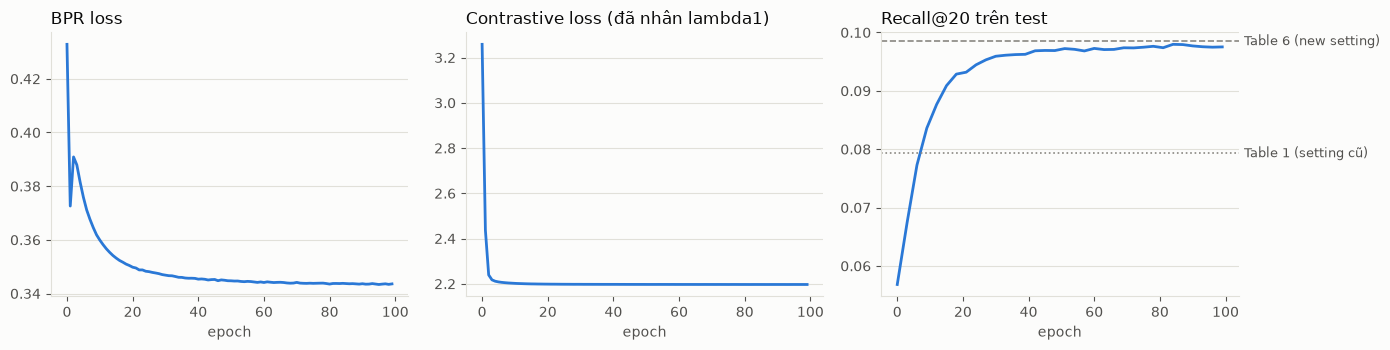

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(14, 3.6))
tested = history.dropna(subset=["recall@20"])
panels = [
    (history["loss_r"], "BPR loss"),
    (history["loss_s"], "Contrastive loss (đã nhân lambda1)"),
    (tested["recall@20"], "Recall@20 trên test"),
]
for ax, (series, title) in zip(axes, panels):
    ax.plot(series.index, series.to_numpy(), color=COLORS["model"], lw=2)
    ax.set_title(title)
    ax.set_xlabel("epoch")
for name, style in zip(PAPER, ["--", ":"]):
    value = PAPER[name]["recall@20"]
    axes[2].axhline(value, color=INK["muted"], lw=1.2, ls=style)
    axes[2].annotate(name.replace("paper ", ""), (1, value), xycoords=("axes fraction", "data"), xytext=(4, 0),
                     textcoords="offset points", va="center", fontsize=9, color=INK["secondary"])
fig.tight_layout()
plt.show()

## 3. So sánh với paper

In [ ]:
tested = history.dropna(subset=["recall@20"])
best_epoch = tested["recall@20"].idxmax()
comparison = pd.DataFrame({
    **PAPER,
    f"notebook, final (sau epoch {cfg.epochs - 1})": final_official,
    f"notebook, epoch test tốt nhất ({best_epoch})": tested.loc[best_epoch, METRICS],
    "notebook, final, trung bình theo user": final_per_user,
}).T[METRICS]
display(fmt_table(comparison))

gap = final_official / pd.Series(PAPER["paper Table 6 (new setting)"]) - 1
print("Final so với Table 6: " + ", ".join(f"{k} {v:+.1%}".replace(".", ",") for k, v in gap.items()))

run_dir = PROJECT_ROOT / "data" / "runs" / f"lightgcl_yelp_{datetime.now(timezone.utc):%Y%m%d_%H%M%S}"
run_dir.mkdir(parents=True, exist_ok=True)
(run_dir / "config.json").write_text(json.dumps(vars(cfg), indent=2))
history.to_csv(run_dir / "history.csv")
comparison.to_csv(run_dir / "comparison.csv")
print(f"Đã lưu vào {run_dir.relative_to(PROJECT_ROOT)}")

,recall@20,ndcg@20,recall@40,ndcg@40
paper Table 6 (new setting),"0,0985","0,0842","0,1553","0,1051"
paper Table 1 (setting cũ),"0,0793","0,0668","0,1292","0,0852"
"notebook, final (sau epoch 99)","0,0975","0,0843","0,1559","0,1055"
"notebook, epoch test tốt nhất (84)","0,098","0,0843","0,1553","0,1051"
"notebook, final, trung bình theo user","0,0974","0,0843","0,1559","0,1055"


Final so với Table 6: recall@20 -1,0%, ndcg@20 +0,1%, recall@40 +0,4%, ndcg@40 +0,4%
Đã lưu vào data/runs/lightgcl_yelp_20260930_025116
